In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , log_loss

In [2]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
X , y = make_classification(n_samples = 300 , n_features = 2 , n_redundant = 0 ,
                            n_informative = 2 , n_clusters_per_class = 1 ,
                            class_sep = 1.2 , flip_y = 0.04 , random_state = 42)

In [3]:
model = Pipeline([("scaler" , StandardScaler()) ,
 ("clf" , LogisticRegression(max_iter = 2000))])
model.fit(X , y)
probs = model.predict_proba(X)
preds = model.predict(X)
scores = model.decision_function(X)
acc = accuracy_score(y , preds)
ce_loss = log_loss(y , probs)
pred_confidence = np.max(probs , axis = 1)
is_correct = preds == y
true_class_prob = probs[np.arange(len(y)) , y]
sample_losses = - np.log(np.clip(true_class_prob , 1e-12 , 1.0))
print(f"Accuracy: {acc:.3f}")
print(f"Cross-Entropy Loss: {ce_loss:.3f}")
x_min , x_max = X[ : , 0].min() - 1.0 , X[ : , 0].max() + 1.0
y_min , y_max = X[ : , 1].min() - 1.0 , X[ : , 1].max() + 1.0
xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                      np.linspace(y_min , y_max , 400))
grid = np.c_[xx.ravel() , yy.ravel()]
grid_probs = model.predict_proba(grid)[ : , 1].reshape(xx.shape)
grid_scores = model.decision_function(grid).reshape(xx.shape)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

Accuracy: 0.930
Cross-Entropy Loss: 0.227


Text(0.5, 1.0, 'Probability Surface (Softmax Output)')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

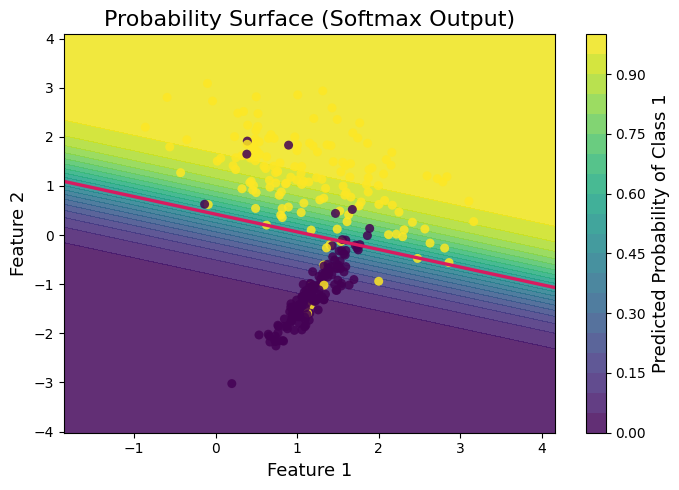

In [4]:
fig , ax = plt.subplots()
ax.grid(False)
prob_contour = ax.contourf(xx , yy , grid_probs , levels = 20 , alpha = 0.85 ,
                           cmap = "viridis")
ax.contour(xx , yy , grid_probs , levels = [0.5] , colors = "#D81B60" ,
           linewidths = 2.4)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 42 , alpha = 0.85 ,
           edgecolors = "none")
cbar = fig.colorbar(prob_contour)
cbar.set_label("Predicted Probability of Class 1")
ax.set_title("Probability Surface (Softmax Output)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Decision Boundary (0.5 Threshold)')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

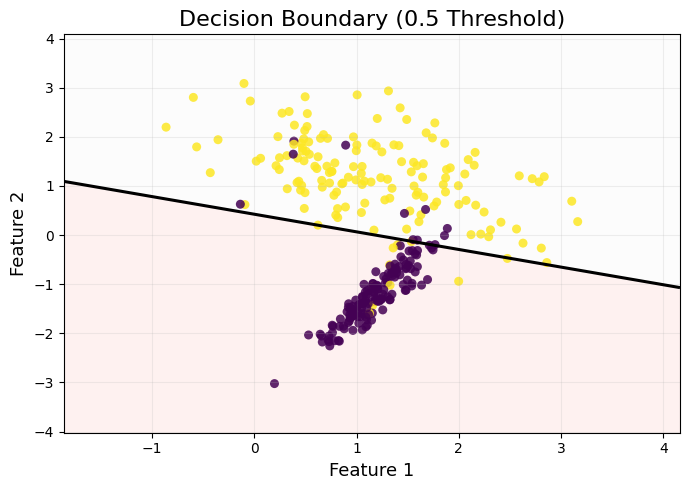

In [5]:
fig , ax = plt.subplots()
ax.contourf(xx , yy , (grid_probs >= 0.5).astype(int) , alpha = 0.18 ,
            cmap = plt.cm.Pastel1)
ax.contour(xx , yy , grid_probs , levels = [0.5] , colors = "black" ,
           linewidths = 2.2)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 42 , alpha = 0.85 ,
           edgecolors = "none")
ax.set_title("Decision Boundary (0.5 Threshold)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Decision Score Surface')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

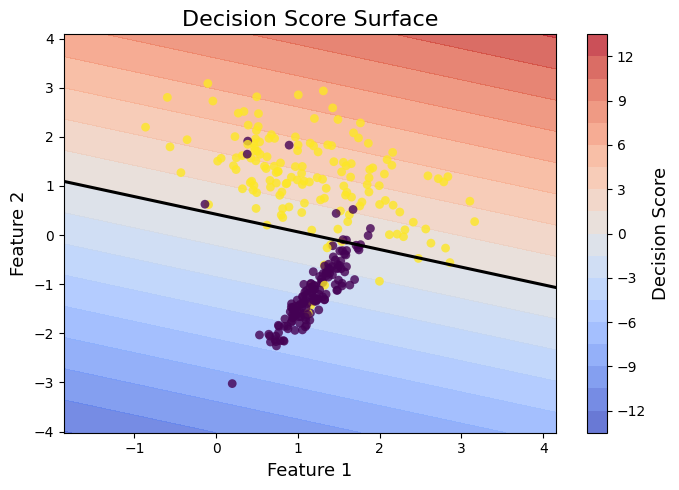

In [6]:
fig , ax = plt.subplots()
ax.grid(False)
score_contour = ax.contourf(xx , yy , grid_scores , levels = 20 , alpha = 0.80 ,
                            cmap = "coolwarm")
ax.contour(xx , yy , grid_scores , levels = [0] , colors = "black" ,
           linewidths = 2.2)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y ,  s = 40 , alpha = 0.80 ,
           edgecolors = "none")
cbar = fig.colorbar(score_contour)
cbar.set_label("Decision Score")
ax.set_title("Decision Score Surface")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.95, 0.1712932943875506, 'p = 0.95')

Text(0.6, 0.6308256237659907, 'p = 0.60')

Text(0.1, 2.4225850929940456, 'p = 0.10')

(0.0, 5.0)

Text(0.5, 0, 'Predicted Probability for the True Class')

Text(0, 0.5, 'Cross-Entropy Penalty')

Text(0.5, 1.0, 'Cross-Entropy Punishes Confident Mistakes')

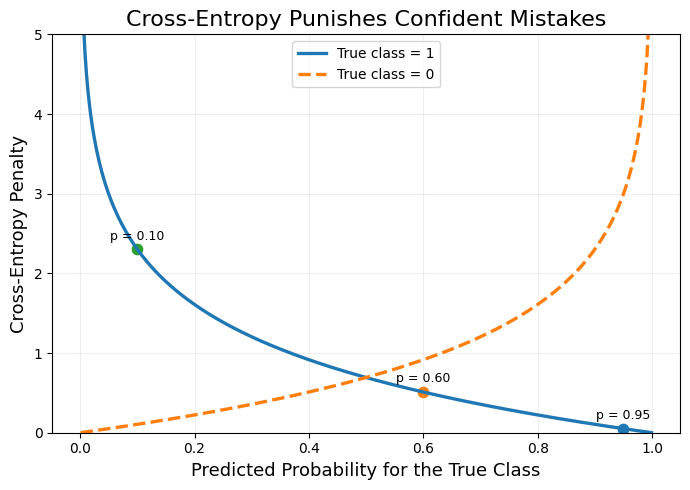

In [7]:
fig , ax = plt.subplots()
p = np.linspace(0.001 , 0.999 , 400)
loss_true_1 = - np.log(p)
loss_true_0 = - np.log(1 - p)
ax.plot(p , loss_true_1 , linewidth = 2.4 , label = "True class = 1")
ax.plot(p , loss_true_0 , linewidth = 2.4 , linestyle = "--" , label = "True class = 0")
example_probs = [0.95 , 0.60 , 0.10]
for ep in example_probs:
    ax.scatter(ep , - np.log(ep) , s = 55)
    ax.text(ep , - np.log(ep) + 0.12 , f"p = {ep:.2f}" , fontsize = 9 , ha = "center")
ax.set_ylim(0 , 5)
ax.set_xlabel("Predicted Probability for the True Class")
ax.set_ylabel("Cross-Entropy Penalty")
ax.set_title("Cross-Entropy Punishes Confident Mistakes")
ax.legend()
fig.tight_layout()
plt.show()

(array([  3.,   3.,   3.,   4.,   4.,   4.,   7.,   4.,   8.,  10.,  15.,
         19.,  30.,  55., 110.]),
 array([0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 15 artists>)

(array([5., 0., 2., 1., 1., 0., 1., 0., 2., 1., 1., 0., 2., 1., 4.]),
 array([0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 15 artists>)

Text(0.5, 1.0, 'Prediction Confidence: Correct vs Incorrect')

Text(0.5, 0, 'Predicted-Class Confidence')

Text(0, 0.5, 'Count')

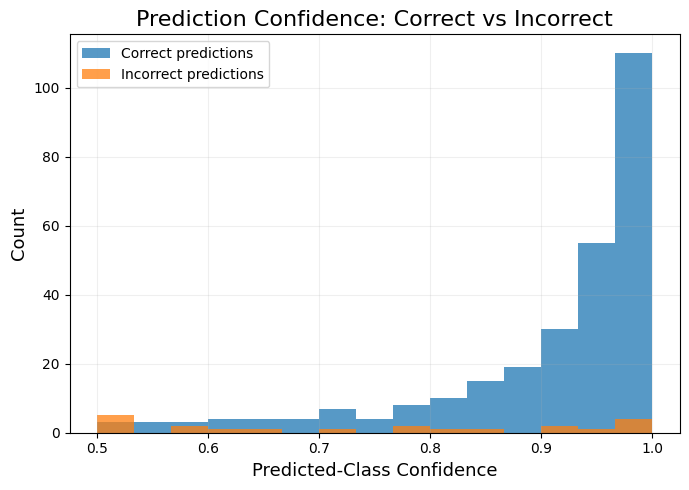

In [8]:
fig , ax = plt.subplots()
correct_conf = pred_confidence[is_correct]
wrong_conf = pred_confidence[~is_correct]
bins = np.linspace(0.5 , 1.0 , 16)
ax.hist(correct_conf , bins = bins , alpha = 0.75 , label = "Correct predictions")
if len(wrong_conf) > 0:
    ax.hist(wrong_conf , bins = bins , alpha = 0.75 , label = "Incorrect predictions")
ax.set_title("Prediction Confidence: Correct vs Incorrect")
ax.set_xlabel("Predicted-Class Confidence")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()

Text(0.5, 0, 'Probability Assigned to the True Class')

Text(0, 0.5, 'Per-Sample Cross-Entropy Loss')

Text(0.5, 1.0, 'True-Class Probability vs Loss')

(0.0, 4.592480595444303)

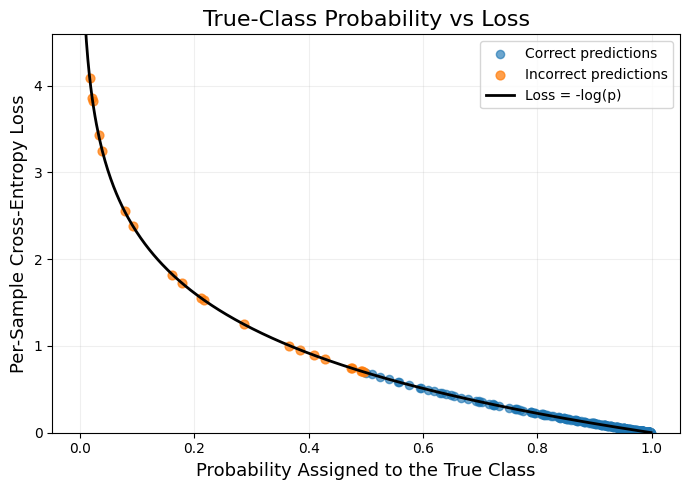

In [9]:
fig , ax = plt.subplots()
ax.scatter(true_class_prob[is_correct] , sample_losses[is_correct] ,
           alpha = 0.65 , s = 35 , label = "Correct predictions")
if np.any(~is_correct):
    ax.scatter(true_class_prob[~is_correct] , sample_losses[~is_correct] ,
               alpha = 0.75 , s = 40 , label = "Incorrect predictions")
p_line = np.linspace(0.001 , 0.999 , 400)
ax.plot(p_line , - np.log(p_line) , color = "black" , linewidth = 2 , label = "Loss = -log(p)")
ax.set_xlabel("Probability Assigned to the True Class")
ax.set_ylabel("Per-Sample Cross-Entropy Loss")
ax.set_title("True-Class Probability vs Loss")
ax.set_ylim(0 , min(5 , sample_losses.max() + 0.5))
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
good_prob = 0.95
okay_prob = 0.60
bad_prob = 0.10
print("\nPenalty examples (assuming the true class probability is p):")
print(f"p = {good_prob:.2f} -> loss = {-np.log(good_prob):.3f}")
print(f"p = {okay_prob:.2f} -> loss = {-np.log(okay_prob):.3f}")
print(f"p = {bad_prob:.2f} -> loss = {-np.log(bad_prob):.3f}")


Penalty examples (assuming the true class probability is p):
p = 0.95 -> loss = 0.051
p = 0.60 -> loss = 0.511
p = 0.10 -> loss = 2.303
